In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from sklearn.metrics import accuracy_score

In [4]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [5]:
print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
#60000 numbers of training images,28 images height,28 images width
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


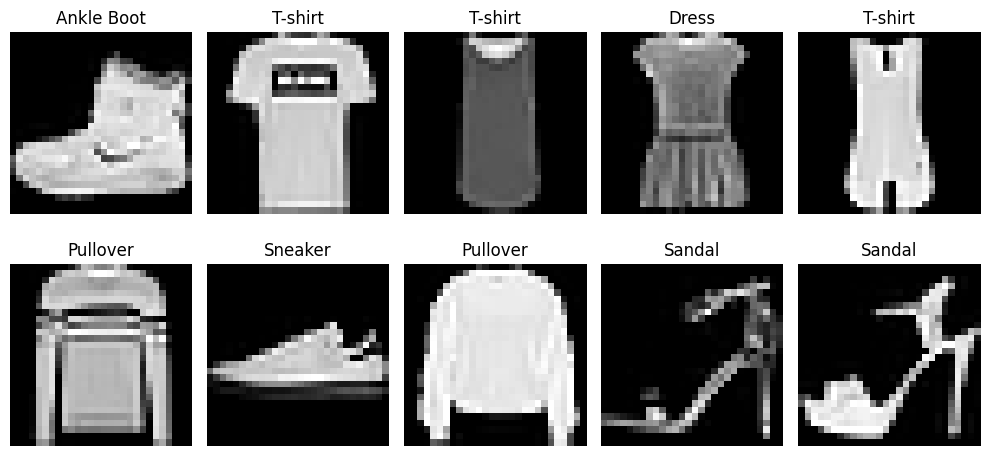

In [6]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
#The pixel values range from 0 to 255. Neural networks train better when values are scaled to 0–1.
X_train = X_train / 255.0
X_test = X_test / 255.0
print(X_train.min())
print(X_train.max())

0.0
1.0


In [9]:
#Ann accepts only 1D vector then we will use Flatten layer to convert each image 28x28 into a 784 element vector
model = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(256,activation = "relu"),
    Dense(128,activation = "relu"),
    Dense(64,activation = "relu"),
    Dense(10,activation = "softmax")
])

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer = "adam",
              loss = "sparse_categorical_crossentropy",
              metrics=["accuracy"]
             )
'''Adam: Efficient optimizer.
Sparse Categorical Crossentropy: Labels are integers (0–9), so one-hot encoding isn't needed.
Accuracy: Measures classification performance.'''

"Adam: Efficient optimizer.\nSparse Categorical Crossentropy: Labels are integers (0–9), so one-hot encoding isn't needed.\nAccuracy: Measures classification performance."

In [12]:
history = model.fit(X_train,y_train,epochs = 10,batch_size = 32,validation_split = 0.2)
history

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8206 - loss: 0.4998 - val_accuracy: 0.8528 - val_loss: 0.4077
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8602 - loss: 0.3772 - val_accuracy: 0.8453 - val_loss: 0.4380
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8757 - loss: 0.3385 - val_accuracy: 0.8736 - val_loss: 0.3455
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8834 - loss: 0.3131 - val_accuracy: 0.8815 - val_loss: 0.3320
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8896 - loss: 0.2957 - val_accuracy: 0.8844 - val_loss: 0.3192
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8949 - loss: 0.2778 - val_accuracy: 0.8711 - val_loss: 0.3589
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9020 - loss: 0.2644 - val_accuracy: 0.8842 - val_loss: 0.3253
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9046 - loss: 0.2534 - 

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:",test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8815 - loss: 0.3665
Test Accuracy: 0.8815000057220459
Test Loss: 0.3664919137954712


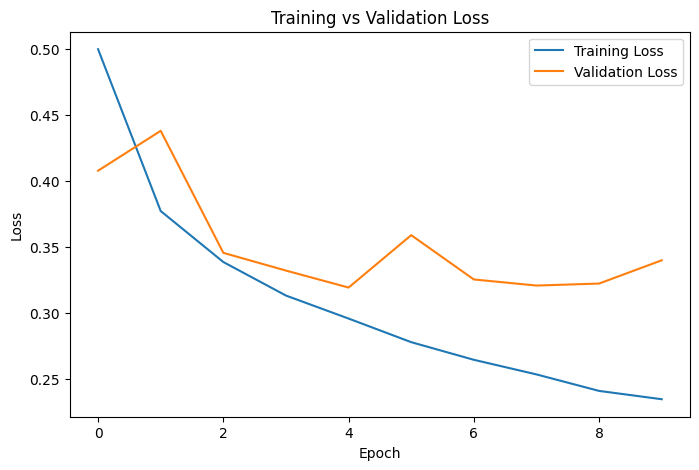

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [15]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step


In [16]:
print(predictions[0])

[4.0817667e-07 1.1536607e-05 7.6807174e-07 1.9108065e-05 1.2859667e-06
 1.6163767e-03 1.9391166e-06 1.7266402e-02 1.7300695e-06 9.8108035e-01]


In [17]:
predicted_labels = np.argmax(predictions, axis=1)

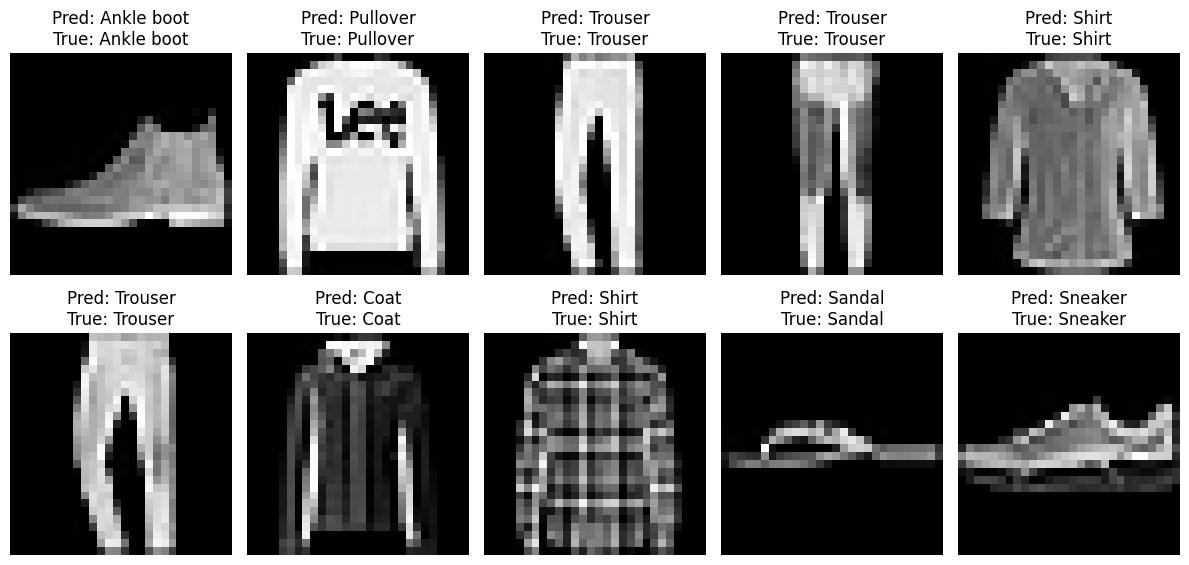

In [18]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Pred: {class_names[predicted_labels[i]]}\nTrue: {class_names[y_test[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


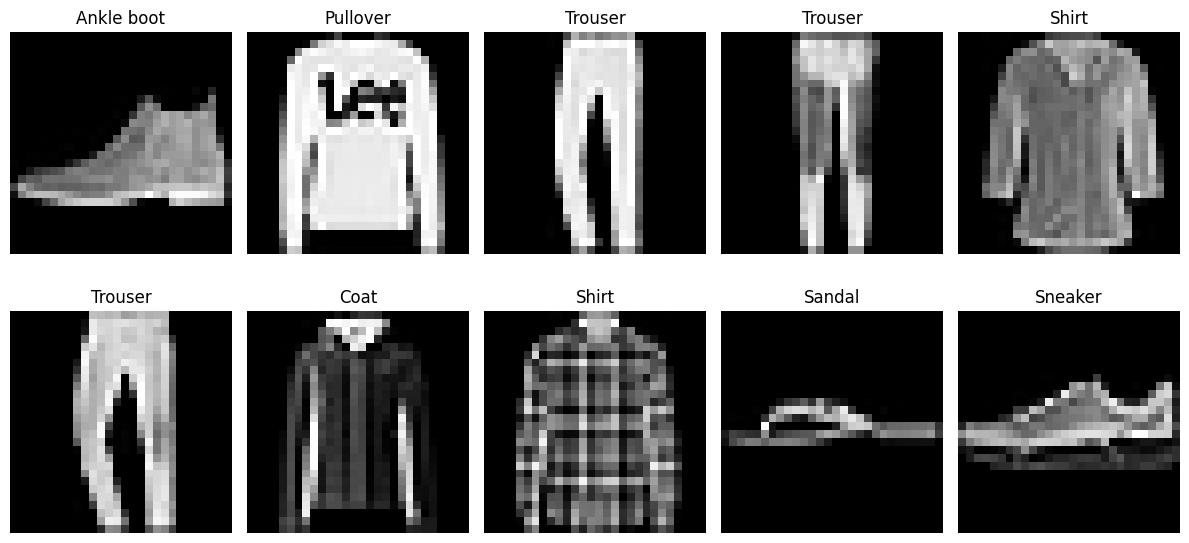

In [19]:
correct = np.where(predicted_labels == y_test)[0]

plt.figure(figsize=(12,6))

for i, idx in enumerate(correct[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(class_names[predicted_labels[idx]])
    plt.axis('off')

plt.tight_layout()
plt.show()

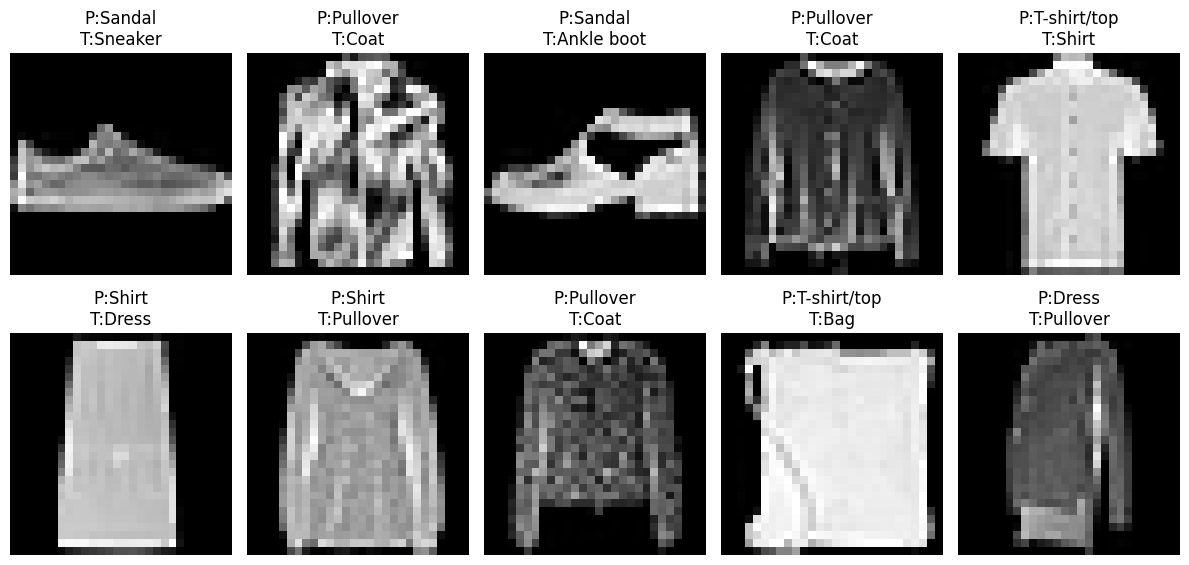

In [20]:
incorrect = np.where(predicted_labels != y_test)[0]

plt.figure(figsize=(12,6))

for i, idx in enumerate(incorrect[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"P:{class_names[predicted_labels[idx]]}\nT:{class_names[y_test[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

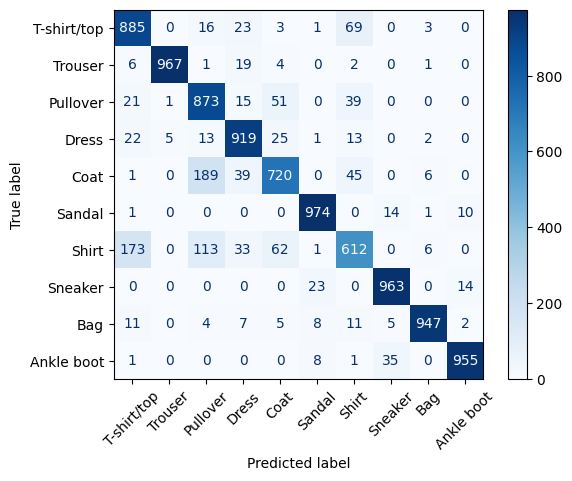

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predicted_labels,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.79      0.89      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.72      0.87      0.79      1000
       Dress       0.87      0.92      0.89      1000
        Coat       0.83      0.72      0.77      1000
      Sandal       0.96      0.97      0.97      1000
       Shirt       0.77      0.61      0.68      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.98      0.95      0.96      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

